# Semantic Search for Lenta.ru News
## Business Task

The user enters a **search query** (“inflation”, “ruble exchange rate”, “Champions League final”), and the system returns relevant articles, even if the exact query words do not appear in the text.

**Goal**: compare a lexical baseline (TF-IDF) with a semantic approach (Word2Vec + cosine similarity) in a production-style setup: configuration, classes, train/index split, metrics, and artifacts.

## Dataset

[zloelias/lenta-ru](https://huggingface.co/datasets/zloelias/lenta-ru) — a Russian news dataset containing categories (topic), headlines, and article texts. It is suitable for search tasks and topic-based validation.

## Pipeline

```text
Loading → EDA → preprocessing → split (train/val/test)
    → indexing (TF-IDF | W2V document vectors) using train only
    → search API → validation (MRR, Recall@k, Topic-Precision@k)
    → method comparison → artifact saving
```

In [100]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import json

import re

import nltk
from nltk.corpus import stopwords as nltk_stopwords
from razdel import tokenize as razdel_tokenize

import gensim
from gensim.models import Word2Vec

from datasets import load_dataset
from dataclasses import asdict, dataclass, field

import sklearn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

In [101]:
def ensure_nltk() -> None:
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords", quiet=True)


ensure_nltk()
STOP_RU = set(nltk_stopwords.words("russian"))

# Компилируется один раз: проверка выполняется на каждый токен корпуса.
# a-z обязателен, иначе теряется латиница: Yamaha, BMW, Stels, Irbis.
TOKEN_RE = re.compile(r"[а-яёa-z]+", re.I)

In [102]:
@dataclass(frozen=True)
class SemanticSearchConfig:
    dataset_id: str = "zloelias/lenta-ru"
    random_state: int = 42
    corpus_sample: int = 8_000

    min_tokens_per_doc: int = 12
    min_word_len: int = 2

    title_boost: int = 3
    tfidf_max_features: int = 20_000
    embed_dim: int = 128

    w2v_window: int = 5
    w2v_min_count: int = 3
    w2v_epochs: int = 15

    lsa_components: int = 200

    search_top_k: int = 10

    hybrid_candidates: int = 50
    hybrid_alpha: float = 0.85

    title_query_tokens: int = 5

    artifacts_dir: Path = field(default_factory=lambda: Path("artifacts"))

    def to_dict(self) -> dict:
        d = asdict(self)
        d["artifacts_dir"] = str(self.artifacts_dir)
        return d

In [103]:
CFG = SemanticSearchConfig()

CFG.artifacts_dir.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG.random_state)

In [104]:
raw = load_dataset(CFG.dataset_id, split="train")
df_all = raw.to_pandas()
df = (
    df_all.groupby("topic", group_keys=False)
          .sample(frac=CFG.corpus_sample / len(df_all), random_state=CFG.random_state)
          .reset_index(drop=True)
)

In [105]:
df["doc_id"] = df.index.astype(str)
df['title'] = df['title'].fillna('').str.strip()
df['text'] = df['text'].fillna('').str.strip()
df["full_text"] = (df["title"] + " " + df["text"]).str.strip()

In [106]:
print("Статей:", len(df))
print(df["topic"].value_counts())
print(df.head(3))
df["full_text"][0]

Статей: 7999
topic
Экономика          2462
Спорт              1997
Культура           1669
Наука и техника    1641
Бизнес              230
Name: count, dtype: int64
                                               title  \
0          Россияне стали покупать больше мотоциклов   
1        Умер создатель брендов «Инвайт» и «Быстров»   
2  Сеть магазинов просроченных продуктов заработа...   

                                                text   topic  labels doc_id  \
0  Продажи новой мототехники в России по итогам п...  Бизнес       4      0   
1  Умер предприниматель Сергей Выходцев, создавши...  Бизнес       4      1   
2  В столице Дании в ноябре открылся второй магаз...  Бизнес       4      2   

                                           full_text  
0  Россияне стали покупать больше мотоциклов Прод...  
1  Умер создатель брендов «Инвайт» и «Быстров» Ум...  
2  Сеть магазинов просроченных продуктов заработа...  


'Россияне стали покупать больше мотоциклов Продажи новой мототехники в России по итогам прошлого года выросли в 1,5 раза, составив 30,2 тысячи единиц. Об этом сообщается в пресс-релизе аналитического агентства «Автостат», поступившем в редакцию «Ленты.ру». Больше всего в 2014-м было продано техники российской компании Irbis — 4,8 тысячи единиц, за ней следуют российско-китайские Stels — 2,9 тысячи — и отечественный Racer — 2,8 тысячи штук. На четвертой и пятой позициях оказались японские Yamaha с 2,5 тысячи проданных единиц техники и Honda — 2 тысячи штук. В январе-марте спрос на мотоциклы упал на 19,6 процента: было продано 2100 штук. Из них больше всего техники немецкой компании BMW (267 единиц), российской Irbis (219 штук) и японской Yamaha (206 штук). Рынок мотоциклов, мотороллеров и другой двухколесной техники в 2014 году вырос на фоне затяжного кризиса на авторынке. В 2014-м, по данным Ассоциации европейского бизнеса, продажи легковых и легких коммерческих автомобилей в РФ упали 

In [107]:
# EDA

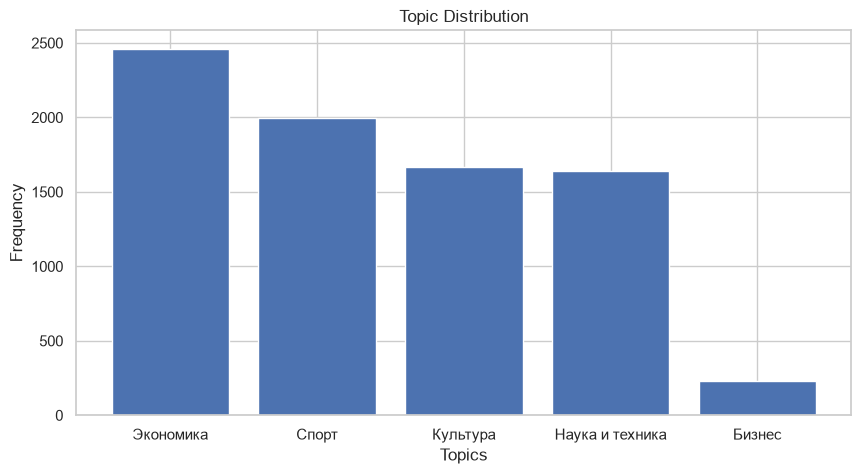

In [108]:
topic_counts = df["topic"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(topic_counts.index, topic_counts.values)

plt.xlabel("Topics")
plt.ylabel("Frequency")
plt.title("Topic Distribution")

plt.show()

In [109]:
df["doc_length"] = df["full_text"].str.split().str.len()
print(df["doc_length"])

0       204
1       166
2       210
3       253
4       216
       ... 
7994    276
7995    220
7996    183
7997    183
7998    223
Name: doc_length, Length: 7999, dtype: int64


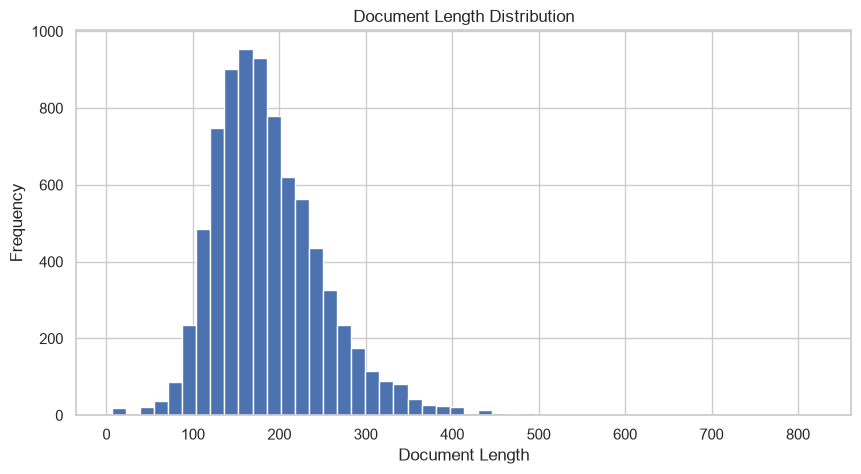

In [110]:
plt.figure(figsize=(10,5))
plt.hist(df["doc_length"],bins=50)

plt.xlabel("Document Length")
plt.ylabel("Frequency")
plt.title("Document Length Distribution")

plt.show()

In [111]:
df["doc_length"].describe()

count    7999.000000
mean      187.551194
std        64.586258
min         6.000000
25%       143.000000
50%       177.000000
75%       222.000000
max       821.000000
Name: doc_length, dtype: float64

  метрика  значение
                 документов    7998.0
                     рубрик       5.0
средняя длина title (симв.)      53.9
 средняя длина text (симв.)    1329.3
   медиана слов в документе     179.0
          уникальных labels       5.0

In [112]:
def corpus_info(docs_len, rubrics, avg_len_title, avg_len_text, median_words):
    return (
        print('documents ', len(docs_len)),
        print('rubrics', *rubrics),
        print('avg_len_title', avg_len_title),
        print('avg_len_text', avg_len_text),
        print('median_words', median_words),
        print('unique_labels', len(rubrics)),
    )

df['text_len'] = df["text"].str.split().str.len()
df['title_len'] = df["title"].str.split().str.len()
df['full_text_len'] = df["full_text"].str.split().str.len()

info = corpus_info(
    df,
    df["topic"].unique(),
    df["title_len"].mean(),
    df["text_len"].mean(),
    df["full_text_len"].median(),
)

documents  7999
rubrics Бизнес Культура Наука и техника Спорт Экономика
avg_len_title 7.344668083510439
avg_len_text 180.20652581572696
median_words 177.0
unique_labels 5


In [113]:
def tokenize_text(text):
    tokens = []

    for token in razdel_tokenize(text):
        word = token.text.lower()

        if len(word) < CFG.min_word_len:
            continue
        if not TOKEN_RE.fullmatch(word):
            continue
        if word in STOP_RU:
            continue

        tokens.append(word)

    return tokens

df['tokens'] = df['full_text'].apply(tokenize_text)
df['tokens_len'] = df['tokens'].str.len()

print(df['tokens_len'].head(5))

0    117
1    118
2    150
3    189
4    164
Name: tokens_len, dtype: int64


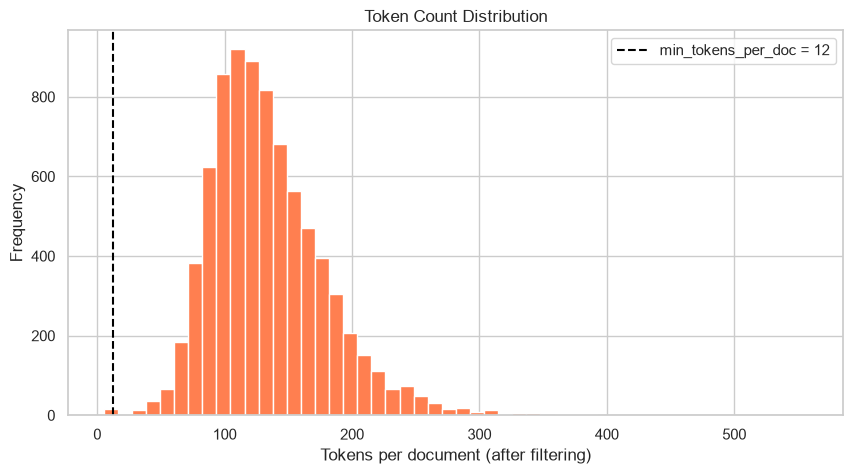

медиана токенов:            127
минимум:                    5
переживёт фильтр:           7987 из 7999
отсечётся:                  12


In [114]:
survivors = (df["tokens_len"] >= CFG.min_tokens_per_doc).sum()

plt.figure(figsize=(10, 5))
plt.hist(df["tokens_len"], bins=50, color="coral", edgecolor="white")
plt.axvline(CFG.min_tokens_per_doc, color="black", ls="--",
            label=f"min_tokens_per_doc = {CFG.min_tokens_per_doc}")

plt.xlabel("Tokens per document (after filtering)")
plt.ylabel("Frequency")
plt.title("Token Count Distribution")
plt.legend()

plt.show()

print(f"медиана токенов:            {df['tokens_len'].median():.0f}")
print(f"минимум:                    {df['tokens_len'].min()}")
print(f"переживёт фильтр:           {survivors} из {len(df)}")
print(f"отсечётся:                  {len(df) - survivors}")

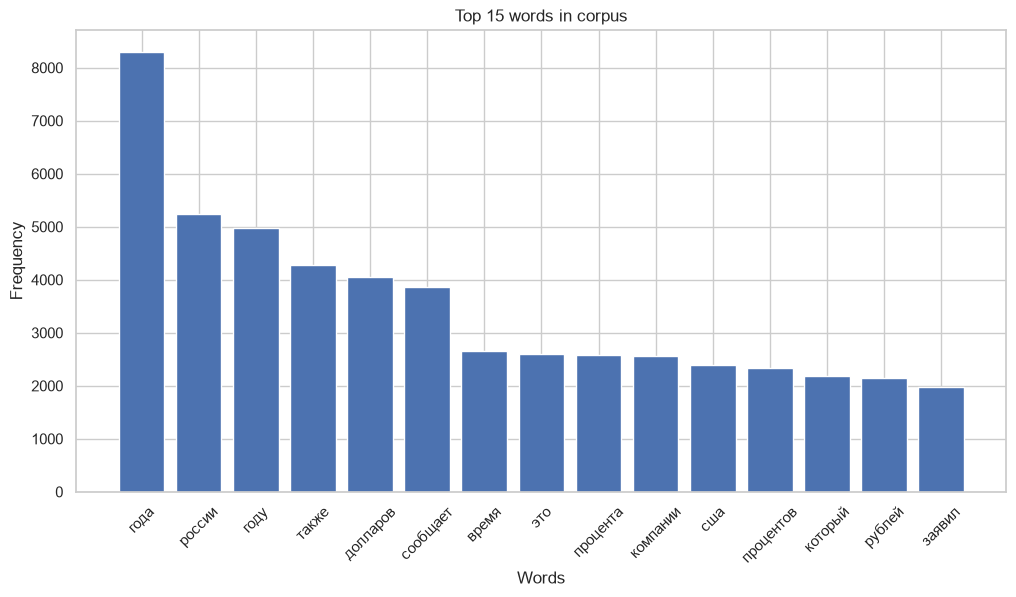

In [115]:
from collections import Counter

word_counts = Counter(word for tokens in df["tokens"] for word in tokens)
top_15 = word_counts.most_common(15)

words = [word for word, count in top_15]
counts = [count for word, count in top_15]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 15 words in corpus")
plt.xticks(rotation=45)

plt.show()


In [116]:
# Preprocessing

corpus = df[df["tokens_len"] >= CFG.min_tokens_per_doc].copy().reset_index(drop=True)
print(len(corpus))

7987


In [117]:
corpus["title_tokens"] = corpus['title'].apply(tokenize_text)
corpus["text_tokens"]  = corpus['text'].apply(tokenize_text)

In [118]:
corpus["index_text"] = corpus.apply(
    lambda row: " ".join(
        list(row["title_tokens"]) * CFG.title_boost + list(row["text_tokens"])
    ),
    axis=1,
)
corpus.head(3)

,title,text,topic,labels,doc_id,full_text,doc_length,text_len,title_len,full_text_len,tokens,tokens_len,title_tokens,text_tokens,index_text
0,Россияне стали покупать больше мотоциклов,Продажи новой мототехники в России по итогам п...,Бизнес,4,0,Россияне стали покупать больше мотоциклов Прод...,204,199,5,204,"[россияне, стали, покупать, мотоциклов, продаж...",117,"[россияне, стали, покупать, мотоциклов]","[продажи, новой, мототехники, россии, итогам, ...",россияне стали покупать мотоциклов россияне ст...
1,Умер создатель брендов «Инвайт» и «Быстров»,"Умер предприниматель Сергей Выходцев, создавши...",Бизнес,4,1,Умер создатель брендов «Инвайт» и «Быстров» Ум...,166,160,6,166,"[умер, создатель, брендов, инвайт, быстров, ум...",118,"[умер, создатель, брендов, инвайт, быстров]","[умер, предприниматель, сергей, выходцев, созд...",умер создатель брендов инвайт быстров умер соз...
2,Сеть магазинов просроченных продуктов заработа...,В столице Дании в ноябре открылся второй магаз...,Бизнес,4,2,Сеть магазинов просроченных продуктов заработа...,210,203,7,210,"[сеть, магазинов, просроченных, продуктов, зар...",150,"[сеть, магазинов, просроченных, продуктов, зар...","[столице, дании, ноябре, открылся, второй, маг...",сеть магазинов просроченных продуктов заработа...


In [119]:
indices = np.arange(len(corpus))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=CFG.random_state,
    stratify=corpus["topic"],
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=CFG.random_state,
    stratify=corpus["topic"].iloc[temp_idx],
)

splits = {
    "train": corpus.iloc[train_idx].reset_index(drop=True),
    "val": corpus.iloc[val_idx].reset_index(drop=True),
    "test": corpus.iloc[test_idx].reset_index(drop=True),
}

for name, part in splits.items():
    print(f"{name:5} | n={len(part):4} | doc_id пример: {part['doc_id'].iloc[0]}")
    print(part["topic"].value_counts().to_string())
    print()

train | n=5590 | doc_id пример: 6070
topic
Экономика          1722
Спорт              1398
Культура           1168
Наука и техника    1141
Бизнес              161

val   | n=1198 | doc_id пример: 3865
topic
Экономика          369
Спорт              299
Культура           250
Наука и техника    245
Бизнес              35

test  | n=1199 | doc_id пример: 3093
topic
Экономика          369
Спорт              300
Культура           251
Наука и техника    245
Бизнес              34



In [120]:
# Index and Search`
# TF-IDF
def tf_idf_vectorizer(cfg: SemanticSearchConfig):
    return TfidfVectorizer(
        max_features=cfg.tfidf_max_features,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
    )

In [121]:
class TfidfBackend:

    def __init__(self, cfg):
        self.cfg = cfg
        self.vectorizer = tf_idf_vectorizer(cfg)
        self.matrix = None
        self.ids = None

    def fit(self, train_texts, index_texts, index_ids):
        self.vectorizer.fit(train_texts)
        self.matrix = normalize(self.vectorizer.transform(index_texts))
        self.ids = np.asarray(index_ids)
        return self

    def search(self, query, top_k=None):
        query_tokens = tokenize_text(query)
        query_text = " ".join(query_tokens)
        query_vector = normalize(self.vectorizer.transform([query_text]))

        k = top_k or self.cfg.search_top_k

        scores = (query_vector @ self.matrix.T).toarray()[0]
        top = np.argpartition(-scores, min(k, len(scores) - 1))[:k]
        top = top[np.argsort(-scores[top])]

        return [(self.ids[i], float(scores[i])) for i in top]

In [123]:
class Word2VecBackend:

    def __init__(self, cfg):
        self.cfg = cfg
        self.model = None          # появится в fit
        self.idf = None            # словарь слово -> вес, появится в fit
        self.default_idf = 1.0     # запасной вес, пересчитывается в fit
        self.matrix = None
        self.ids = None

    def _doc_vector(self, tokens):
        known_words = [word for word in tokens if word in self.model.wv]
        if not known_words:
            return np.zeros(self.cfg.embed_dim)

        vectors = np.array([self.model.wv[word] for word in known_words])
        weights = np.array([self.idf.get(word, self.default_idf) for word in known_words])

        return np.average(vectors, axis=0, weights=weights)

    def fit(self, train_texts, index_texts, index_ids):
        train_tokens = [t.split() for t in train_texts]

        self.model = Word2Vec(
            sentences=train_tokens,
            vector_size=self.cfg.embed_dim,
            window=self.cfg.w2v_window,
            min_count=self.cfg.w2v_min_count,
            epochs=self.cfg.w2v_epochs,
            seed=self.cfg.random_state,
            workers=1,
        )

        tfidf = tf_idf_vectorizer(self.cfg)
        tfidf.fit(train_texts)
        self.idf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
        self.default_idf = float(np.mean(tfidf.idf_))

        self.matrix = normalize(
            np.vstack([self._doc_vector(t.split()) for t in index_texts])
        )
        self.ids = np.asarray(index_ids)
        return self

    def search(self, query, top_k=None):
        k = top_k or self.cfg.search_top_k

        query_vector = self._doc_vector(tokenize_text(query)).reshape(1, -1)
        query_vector = normalize(query_vector)

        scores = (query_vector @ self.matrix.T)[0]

        top = np.argpartition(-scores, min(k, len(scores) - 1))[:k]
        top = top[np.argsort(-scores[top])]

        return [(self.ids[i], float(scores[i])) for i in top]